# Article Analysis

Este notebook lê apenas os artefatos salvos pelos scripts de treino e gera tabelas e gráficos para o trabalho, incluindo comparações de custo computacional quando disponíveis.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'src').exists() and (REPO_ROOT.parent / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent

RUN_ROOT = REPO_ROOT / 'outputs' / 'cla_lora_runs'
if not RUN_ROOT.exists() and (REPO_ROOT / 'cla_lora_runs').exists():
    RUN_ROOT = REPO_ROOT / 'cla_lora_runs'

SELECTED_RUNS = {
    'full_finetune': '',
    'lora': '',
    'adalora': '',
}

K = 4

In [24]:
def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

def load_csv_optional(path):
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()

def safe_div(num, den):
    if num is None or den is None:
        return None
    if pd.isna(num) or pd.isna(den) or den == 0:
        return None
    return num / den

def first_not_none(*values):
    for value in values:
        if value is not None and not pd.isna(value):
            return value
    return None

def load_run(method):
    run_name = SELECTED_RUNS[method]
    if not run_name:
        return None

    run_dir = RUN_ROOT / method / run_name
    if not run_dir.exists():
        return None

    config = load_json(run_dir / 'config.json')
    summary = load_json(run_dir / 'summary.json')
    history = pd.read_csv(run_dir / 'train_history.csv')
    hardware_info_path = run_dir / 'hardware_info.json'
    hardware_info = load_json(hardware_info_path) if hardware_info_path.exists() else {}
    hardware_history = load_csv_optional(run_dir / 'hardware_history.csv')
    return {
        'run_dir': run_dir,
        'config': config,
        'summary': summary,
        'history': history,
        'hardware_info': hardware_info,
        'hardware_history': hardware_history,
        'deltas': torch.load(run_dir / 'target_deltas.pt', map_location='cpu'),
        'svdvals': torch.load(run_dir / 'target_svdvals.pt', map_location='cpu'),
        'layer_stats': load_json(run_dir / 'layer_stats.json'),
        'display_name': config.get('display_name', method),
    }

def principal_subspace(delta, side, k):
    u, s, vh = torch.linalg.svd(delta.float(), full_matrices=False)
    if s.numel() == 0:
        return None
    rank = min(k, s.numel())
    if side == 'left':
        return u[:, :rank]
    return vh[:rank, :].T

def subspace_similarity(delta_ref, delta_cmp, k):
    metrics = {}
    for side in ['left', 'right']:
        basis_ref = principal_subspace(delta_ref, side, k)
        basis_cmp = principal_subspace(delta_cmp, side, k)
        gram = basis_ref.T @ basis_cmp
        cosines = torch.linalg.svdvals(gram).clamp(0.0, 1.0)
        angles = torch.rad2deg(torch.acos(cosines))
        overlap = torch.linalg.matrix_norm(gram, ord='fro').item() ** 2 / gram.shape[0]
        metrics[f'{side}_mean_cosine'] = cosines.mean().item()
        metrics[f'{side}_max_angle_deg'] = angles.max().item()
        metrics[f'{side}_overlap'] = overlap
    return metrics


In [25]:
runs = {}
load_issues = []

for method in SELECTED_RUNS:
    if not SELECTED_RUNS[method]:
        load_issues.append(f'Selecione um run para {method} em SELECTED_RUNS.')
        continue

    run = load_run(method)
    if run is None:
        load_issues.append(f'Run não encontrado para {method}: {SELECTED_RUNS[method]}')
        continue

    runs[method] = run

audit_rows = []
for method, run in runs.items():
    config = run['config']
    history = run['history']
    hardware_history = run['hardware_history']
    audit_rows.append({
        'method': run['display_name'],
        'run_dir': str(run['run_dir']),
        'comparison_suite_id': config.get('comparison_suite_id'),
        'loss_protocol': config.get('loss_protocol'),
        'max_length': config.get('max_length'),
        'seed': config.get('seed'),
        'learning_rate': config.get('learning_rate'),
        'effective_batch_size': config.get('effective_batch_size'),
        'num_epochs': config.get('num_epochs'),
        'epoch_minus_one_present': bool((history['epoch'] == -1).any()),
        'legacy_test_loss_column': 'legacy_test_loss' in history.columns,
        'hardware_info_available': bool(run['hardware_info']),
        'hardware_history_available': not hardware_history.empty,
        'hardware_epoch_rows': int((hardware_history['epoch'] >= 0).sum()) if not hardware_history.empty and 'epoch' in hardware_history.columns else 0,
        'gpu_name': run['hardware_info'].get('gpu_name'),
    })

if audit_rows:
    display(pd.DataFrame(audit_rows))
else:
    print('Nenhum run carregado.')

if load_issues:
    print('Pendências de carregamento:')
    for issue in load_issues:
        print(f'- {issue}')


,method,run_dir,comparison_suite_id,loss_protocol,max_length,seed,learning_rate,effective_batch_size,num_epochs,epoch_minus_one_present,legacy_test_loss_column,hardware_info_available,hardware_history_available,hardware_epoch_rows,gpu_name
0,full_finetune,/content/drive/MyDrive/cla_lora_runs/full_sess...,legacy_controlled_v1,legacy,128,42,0.00005,32,5,True,True,True,True,5,NVIDIA L4
1,lora,/content/drive/MyDrive/cla_lora_runs/lora_sess...,legacy_controlled_v1,legacy,128,42,0.00005,32,5,True,True,True,True,5,NVIDIA L4
2,adalora,/content/drive/MyDrive/cla_lora_runs/adalora_s...,legacy_controlled_v1,legacy,128,42,0.00005,32,5,True,True,True,True,5,NVIDIA L4


In [26]:
summary_rows = []
for method, run in runs.items():
    summary = run['summary']
    summary_rows.append({
        'method': run['display_name'],
        'trainable_params': summary.get('trainable_params'),
        'trainable_pct': summary.get('trainable_pct'),
        'pretrain_legacy_test_loss': summary.get('pretrain_legacy_test_loss'),
        'final_legacy_test_loss': summary.get('final_legacy_test_loss'),
        'final_train_model_loss': summary.get('final_train_model_loss'),
        'final_train_objective_loss': summary.get('final_train_objective_loss'),
        'total_time_sec': summary.get('total_time_sec'),
        'seconds_per_epoch': safe_div(summary.get('total_time_sec'), run['config'].get('num_epochs')),
    })

if summary_rows:
    display(pd.DataFrame(summary_rows))

print('Obs.: use train_objective_loss do AdaLoRA apenas como diagnóstico do próprio método, porque ela inclui regularização.')


,method,trainable_params,trainable_pct,pretrain_legacy_test_loss,final_legacy_test_loss,final_train_model_loss,final_train_objective_loss,total_time_sec,seconds_per_epoch
0,full_finetune,124439808,100.000000,8.464597,1.901117,1.621320,1.621320,1381.772149,276.354430
1,lora,589824,0.471747,8.464597,1.938724,2.096707,2.096707,1257.941292,251.588258
2,adalora,590016,0.471900,8.464597,2.079946,2.272672,2.273007,1296.091409,259.218282


Obs.: use train_objective_loss do AdaLoRA apenas como diagnóstico do próprio método, porque ela inclui regularização.


In [27]:
required_methods = ['full_finetune', 'lora', 'adalora']
comparison_issues = []

for method in required_methods:
    if method not in runs:
        comparison_issues.append(f'Método ausente na comparação principal: {method}')

if not comparison_issues:
    required_equal_fields = [
        'comparison_suite_id',
        'loss_protocol',
        'max_length',
        'seed',
        'learning_rate',
        'effective_batch_size',
        'num_epochs',
    ]

    for field in required_equal_fields:
        values = {runs[method]['config'].get(field) for method in required_methods}
        if None in values or len(values) != 1:
            comparison_issues.append(f'Campo incompatível para a curva principal: {field} -> {sorted(values, key=str)}')

    for method in required_methods:
        history = runs[method]['history']
        if 'legacy_test_loss' not in history.columns:
            comparison_issues.append(f'{method} não possui a coluna legacy_test_loss.')
        if not (history['epoch'] == -1).any():
            comparison_issues.append(f'{method} não possui a avaliação inicial com epoch = -1.')

if comparison_issues:
    print('Auditoria de compatibilidade:')
    for issue in comparison_issues:
        print(f'- {issue}')
else:
    print('Os runs selecionados estão compatíveis para a curva principal em legacy_test_loss.')


Os runs selecionados estão compatíveis para a curva principal em legacy_test_loss.


In [41]:
history.keys()

Index(['epoch', 'phase', 'train_loss', 'train_model_loss',
       'train_objective_loss', 'legacy_test_loss', 'test_loss',
       'optimizer_steps_epoch', 'optimizer_steps_total', 'epoch_time_sec',
       'cumulative_time_sec'],
      dtype='object')

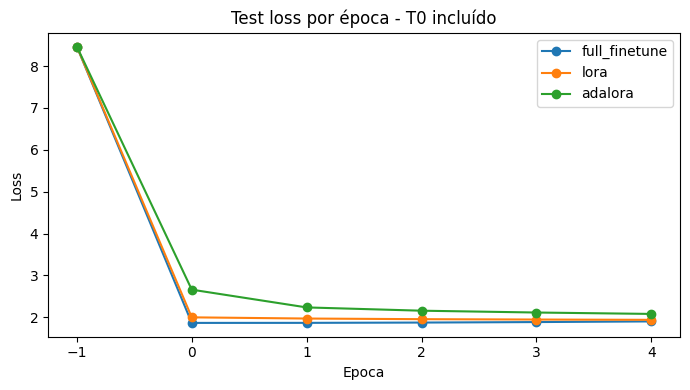

In [28]:
if comparison_issues:
    print('A curva principal foi bloqueada pela auditoria de compatibilidade.')
else:
    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    for method in required_methods:
        history = runs[method]['history'].sort_values('epoch')
        ax.plot(
            history['epoch'],
            history['legacy_test_loss'],
            marker='o',
            label=runs[method]['display_name'],
        )
    ax.set_title('Test loss por época - T0 incluído')
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Loss')
    ax.legend()
    plt.tight_layout()


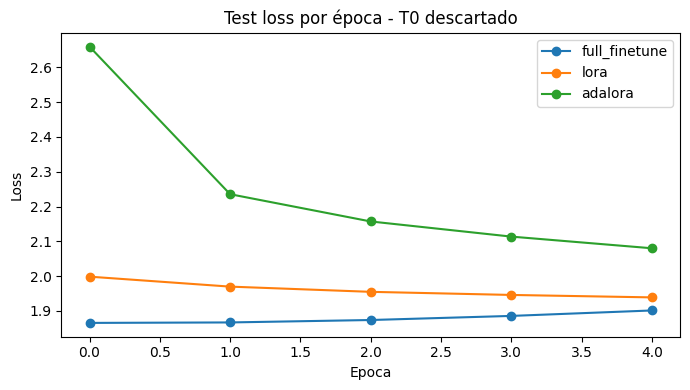

In [29]:
if comparison_issues:
    print('A curva principal foi bloqueada pela auditoria de compatibilidade.')
else:
    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    for method in required_methods:
        history = runs[method]['history'].sort_values('epoch')
        ax.plot(
            history['epoch'][1:],
            history['legacy_test_loss'][1:],
            marker='o',
            label=runs[method]['display_name'],
        )
    ax.set_title('Test loss por época - T0 descartado')
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Loss')
    ax.legend()
    plt.tight_layout()

In [30]:
masked_methods = [method for method in required_methods if method in runs and 'masked_test_loss' in runs[method]['history'].columns]
if masked_methods:
    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    for method in masked_methods:
        history = runs[method]['history'].sort_values('epoch')
        ax.plot(
            history['epoch'],
            history['masked_test_loss'],
            marker='o',
            label=runs[method]['display_name'],
        )
    ax.set_title('Masked test loss por época (diagnóstico)')
    ax.set_xlabel('Epoca')
    ax.set_ylabel('Loss')
    ax.legend()
    plt.tight_layout()
else:
    print('Nenhum run selecionado possui masked_test_loss. Isso é esperado se você estiver usando apenas o protocolo legacy_controlled_v1.')


Nenhum run selecionado possui masked_test_loss. Isso é esperado se você estiver usando apenas o protocolo legacy_controlled_v1.


In [31]:
resource_rows = []
for method, run in runs.items():
    summary = run['summary']
    hardware_info = run['hardware_info']
    hardware_history = run['hardware_history']
    resource_rows.append({
        'method': run['display_name'],
        #'device': hardware_info.get('device', run['config'].get('device')),
        #'gpu_name': hardware_info.get('gpu_name'),
        #'ram_total_gb': hardware_info.get('system_ram_total_gb'),
        #'gpu_total_memory_mb': hardware_info.get('gpu_total_memory_mb'),
        #'hardware_epochs_logged': int((hardware_history['epoch'] >= 0).sum()) if not hardware_history.empty and 'epoch' in hardware_history.columns else 0,
        'peak_process_ram_rss_gb': summary.get('peak_process_ram_rss_gb'),
        'peak_system_ram_used_gb': summary.get('peak_system_ram_used_gb'),
        'peak_gpu_mem_used_mb': summary.get('peak_gpu_mem_used_mb'),
        'peak_gpu_allocated_mb': summary.get('peak_gpu_allocated_mb'),
        'peak_gpu_reserved_mb': summary.get('peak_gpu_reserved_mb'),
        'mean_system_cpu_percent': summary.get('mean_system_cpu_percent'),
        'mean_gpu_util_percent': summary.get('mean_gpu_util_percent'),
    })

if resource_rows:
    display(pd.DataFrame(resource_rows))
else:
    print('Nenhum run carregado para a tabela de recursos computacionais.')


,method,peak_process_ram_rss_gb,peak_system_ram_used_gb,peak_gpu_mem_used_mb,peak_gpu_allocated_mb,peak_gpu_reserved_mb,mean_system_cpu_percent,mean_gpu_util_percent
0,full_finetune,2.176018,5.751415,10714.0,9025.815430,10472.0,12.076046,97.381046
1,lora,1.835194,5.207111,8766.0,8050.935059,8524.0,11.916419,96.364890
2,adalora,2.029362,5.510071,10350.0,8434.970703,10108.0,10.736338,93.358004


In [32]:
ordered_methods = [method for method in ['full_finetune', 'lora', 'adalora'] if method in runs]
reference_cost_method = 'full_finetune' if 'full_finetune' in runs else (ordered_methods[0] if ordered_methods else None)

if reference_cost_method is None:
    print('Nenhum run carregado para a comparação relativa de custo.')
else:
    ref_summary = runs[reference_cost_method]['summary']
    ref_time = ref_summary.get('total_time_sec')
    ref_peak_gpu = first_not_none(ref_summary.get('peak_gpu_allocated_mb'), ref_summary.get('peak_gpu_mem_used_mb'))
    ref_peak_ram = ref_summary.get('peak_process_ram_rss_gb')
    ref_loss = ref_summary.get('final_legacy_test_loss')

    resource_comparison_rows = []
    for method in ordered_methods:
        summary = runs[method]['summary']
        current_time = summary.get('total_time_sec')
        current_peak_gpu = first_not_none(summary.get('peak_gpu_allocated_mb'), summary.get('peak_gpu_mem_used_mb'))
        current_peak_ram = summary.get('peak_process_ram_rss_gb')
        current_loss = summary.get('final_legacy_test_loss')
        resource_comparison_rows.append({
            'method': runs[method]['display_name'],
            'reference': runs[reference_cost_method]['display_name'],
            'time_ratio_vs_reference': safe_div(current_time, ref_time),
            'speedup_vs_reference': safe_div(ref_time, current_time),
            'peak_gpu_ratio_vs_reference': safe_div(current_peak_gpu, ref_peak_gpu),
            'peak_ram_ratio_vs_reference': safe_div(current_peak_ram, ref_peak_ram),
            'final_loss_delta_vs_reference': None if current_loss is None or ref_loss is None or pd.isna(current_loss) or pd.isna(ref_loss) else current_loss - ref_loss,
        })

    display(pd.DataFrame(resource_comparison_rows))


,method,reference,time_ratio_vs_reference,speedup_vs_reference,peak_gpu_ratio_vs_reference,peak_ram_ratio_vs_reference,final_loss_delta_vs_reference
0,full_finetune,full_finetune,1.000000,1.000000,1.000000,1.000000,0.000000
1,lora,full_finetune,0.910383,1.098439,0.891990,0.843373,0.037607
2,adalora,full_finetune,0.937992,1.066107,0.934538,0.932603,0.178830


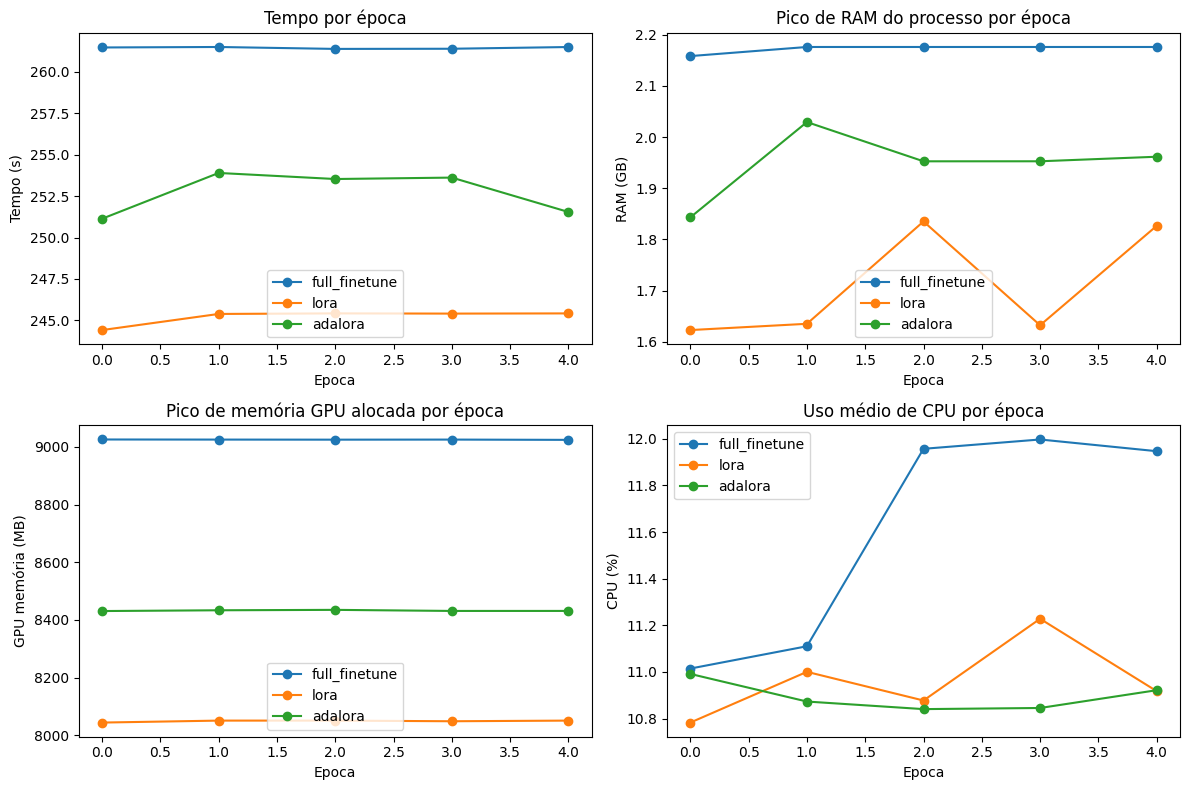

In [33]:
resource_series_specs = [
    ('history', 'epoch_time_sec', 'Tempo por época', 'Tempo (s)'),
    ('hardware_history', 'process_ram_rss_gb_max', 'Pico de RAM do processo por época', 'RAM (GB)'),
    ('hardware_history', 'gpu_peak_allocated_mb', 'Pico de memória GPU alocada por época', 'GPU memória (MB)'),
    ('hardware_history', 'system_cpu_percent_mean', 'Uso médio de CPU por época', 'CPU (%)'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plotted_any = False

for ax, (source_name, column_name, title, ylabel) in zip(axes.flatten(), resource_series_specs):
    plotted_this_axis = False
    for method, run in runs.items():
        df = run[source_name]
        if df.empty or column_name not in df.columns:
            continue

        filtered = df.copy()
        if 'phase' in filtered.columns:
            filtered = filtered[filtered['phase'] == 'epoch_end']
        if 'epoch' in filtered.columns:
            filtered = filtered[filtered['epoch'] >= 0].sort_values('epoch')
        if filtered.empty or filtered[column_name].notna().sum() == 0:
            continue

        ax.plot(filtered['epoch'], filtered[column_name], marker='o', label=run['display_name'])
        plotted_this_axis = True
        plotted_any = True

    if plotted_this_axis:
        ax.set_title(title)
        ax.set_xlabel('Epoca')
        ax.set_ylabel(ylabel)
        ax.legend()
    else:
        ax.set_axis_off()

if plotted_any:
    plt.tight_layout()
else:
    plt.close(fig)
    print('Nenhum run selecionado possui séries de hardware suficientes para os gráficos por época.')


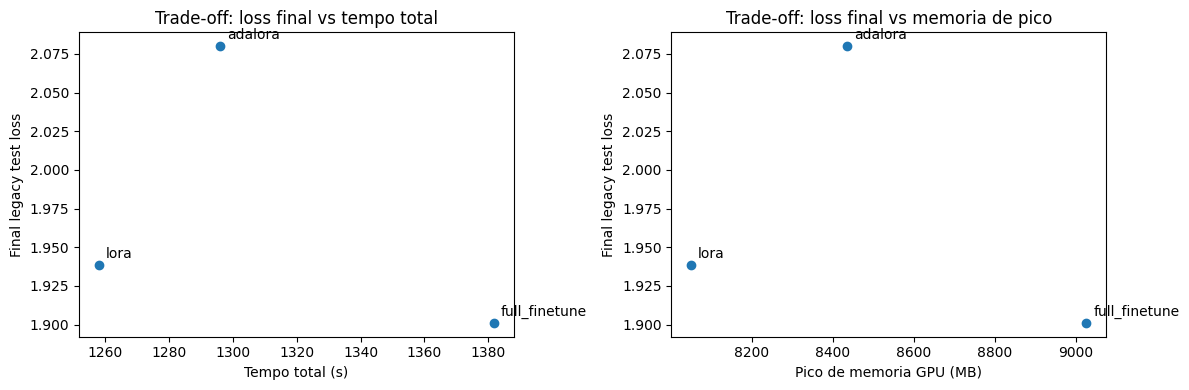

In [34]:
tradeoff_rows = []
for method, run in runs.items():
    summary = run['summary']
    tradeoff_rows.append({
        'method': run['display_name'],
        'final_legacy_test_loss': summary.get('final_legacy_test_loss'),
        'total_time_sec': summary.get('total_time_sec'),
        'peak_gpu_allocated_mb': first_not_none(summary.get('peak_gpu_allocated_mb'), summary.get('peak_gpu_mem_used_mb')),
        'peak_process_ram_rss_gb': summary.get('peak_process_ram_rss_gb'),
    })

tradeoff_df = pd.DataFrame(tradeoff_rows)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

time_df = tradeoff_df.dropna(subset=['total_time_sec', 'final_legacy_test_loss'])
if not time_df.empty:
    axes[0].scatter(time_df['total_time_sec'], time_df['final_legacy_test_loss'])
    for _, row in time_df.iterrows():
        axes[0].annotate(row['method'], (row['total_time_sec'], row['final_legacy_test_loss']), xytext=(5, 5), textcoords='offset points')
    axes[0].set_title('Trade-off: loss final vs tempo total')
    axes[0].set_xlabel('Tempo total (s)')
    axes[0].set_ylabel('Final legacy test loss')
else:
    axes[0].set_axis_off()

memory_metric = 'peak_gpu_allocated_mb' if tradeoff_df['peak_gpu_allocated_mb'].notna().any() else 'peak_process_ram_rss_gb'
memory_label = 'Pico de memoria GPU (MB)' if memory_metric == 'peak_gpu_allocated_mb' else 'Pico de RAM do processo (GB)'
memory_df = tradeoff_df.dropna(subset=[memory_metric, 'final_legacy_test_loss'])
if not memory_df.empty:
    axes[1].scatter(memory_df[memory_metric], memory_df['final_legacy_test_loss'])
    for _, row in memory_df.iterrows():
        axes[1].annotate(row['method'], (row[memory_metric], row['final_legacy_test_loss']), xytext=(5, 5), textcoords='offset points')
    axes[1].set_title('Trade-off: loss final vs memoria de pico')
    axes[1].set_xlabel(memory_label)
    axes[1].set_ylabel('Final legacy test loss')
else:
    axes[1].set_axis_off()

if time_df.empty and memory_df.empty:
    plt.close(fig)
    print('Os runs selecionados nao possuem dados suficientes para o gráfico de trade-off custo-qualidade.')
else:
    plt.tight_layout()


In [35]:
reference_method = next((method for method in ['full_finetune', 'lora', 'adalora'] if method in runs), None)
attention_layers = []

if reference_method is not None:
    attention_layers = sorted([
        name for name in runs[reference_method]['deltas'].keys()
        if '.attn.c_attn' in name
    ])

attention_layers[:3]


['transformer.h.0.attn.c_attn',
 'transformer.h.1.attn.c_attn',
 'transformer.h.10.attn.c_attn']

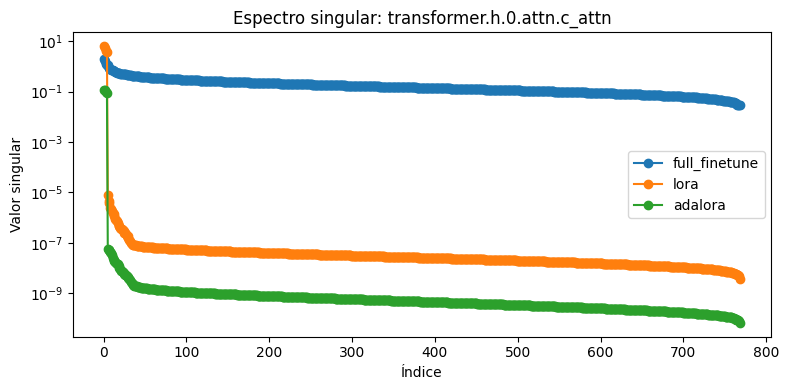

In [36]:
if attention_layers:
    layer_name = attention_layers[0]
    plt.figure(figsize=(8, 4))
    for method, run in runs.items():
        svdvals = run['svdvals'][layer_name]
        plt.plot(range(1, len(svdvals) + 1), svdvals.numpy(), marker='o', label=run['display_name'])
    plt.yscale('log')
    plt.title(f'Espectro singular: {layer_name}')
    plt.xlabel('Índice')
    plt.ylabel('Valor singular')
    plt.legend()
    plt.tight_layout()
else:
    print('Nenhuma camada de atenção disponível para plotar.')


In [37]:
svd_rows = []
for method, run in runs.items():
    for layer_name, stats in run['layer_stats'].items():
        if '.attn.c_attn' in layer_name:
            svd_rows.append({
                'method': run['display_name'],
                'layer': layer_name,
                'stable_rank': stats['stable_rank'],
                'energy_90_rank': stats['energy_90_rank'],
                'energy_95_rank': stats['energy_95_rank'],
            })
pd.DataFrame(svd_rows)


,method,layer,stable_rank,energy_90_rank,energy_95_rank
0,full_finetune,transformer.h.0.attn.c_attn,12.373869,352,469
1,full_finetune,transformer.h.1.attn.c_attn,21.363171,288,392
2,full_finetune,transformer.h.2.attn.c_attn,23.161821,292,395
3,full_finetune,transformer.h.3.attn.c_attn,49.480592,326,432
4,full_finetune,transformer.h.4.attn.c_attn,64.206663,350,457
5,full_finetune,transformer.h.5.attn.c_attn,48.537991,370,477
6,full_finetune,transformer.h.6.attn.c_attn,66.754836,372,480
7,full_finetune,transformer.h.7.attn.c_attn,65.222239,385,493
8,full_finetune,transformer.h.8.attn.c_attn,50.331039,378,487
9,full_finetune,transformer.h.9.attn.c_attn,50.054273,384,493


In [38]:
similarity_rows = []
base_method = 'full_finetune' if 'full_finetune' in runs else ('lora' if 'lora' in runs else None)

if base_method is not None:
    comparison_methods = [method for method in ['lora', 'adalora'] if method in runs and method != base_method]
    for method in comparison_methods:
        for layer_name in attention_layers:
            metrics = subspace_similarity(
                runs[base_method]['deltas'][layer_name],
                runs[method]['deltas'][layer_name],
                K,
            )
            similarity_rows.append({
                'reference': runs[base_method]['display_name'],
                'method': runs[method]['display_name'],
                'layer': layer_name,
                **metrics,
            })

pd.DataFrame(similarity_rows)


,reference,method,layer,left_mean_cosine,left_max_angle_deg,left_overlap,right_mean_cosine,right_max_angle_deg,right_overlap
0,full_finetune,lora,transformer.h.0.attn.c_attn,0.172362,89.181686,0.043834,0.045949,89.621201,0.002870
1,full_finetune,lora,transformer.h.1.attn.c_attn,0.204460,88.788246,0.073414,0.034363,89.493248,0.001704
2,full_finetune,lora,transformer.h.10.attn.c_attn,0.116416,89.623962,0.025252,0.031213,89.808922,0.001351
3,full_finetune,lora,transformer.h.11.attn.c_attn,0.170694,89.315910,0.047929,0.038586,89.865028,0.002173
4,full_finetune,lora,transformer.h.2.attn.c_attn,0.165781,89.820107,0.043660,0.043596,89.698303,0.002796
5,full_finetune,lora,transformer.h.3.attn.c_attn,0.190763,88.651932,0.055885,0.037054,89.239708,0.001776
6,full_finetune,lora,transformer.h.4.attn.c_attn,0.191267,84.102821,0.046580,0.035481,89.517082,0.001968
7,full_finetune,lora,transformer.h.5.attn.c_attn,0.124230,88.938065,0.021660,0.031189,89.731125,0.001671
8,full_finetune,lora,transformer.h.6.attn.c_attn,0.162477,89.791016,0.048387,0.028506,89.927231,0.001307
9,full_finetune,lora,transformer.h.7.attn.c_attn,0.120883,87.800911,0.025193,0.033503,89.747299,0.001509


In [39]:
adalora_mlp_rows = []
if 'adalora' in runs:
    for layer_name, stats in runs['adalora']['layer_stats'].items():
        if '.mlp.' in layer_name:
            adalora_mlp_rows.append({'layer': layer_name, **stats})
pd.DataFrame(adalora_mlp_rows).head()


,layer,shape,fro_norm,spectral_norm,stable_rank,energy_90_rank,energy_95_rank,effective_rank
0,transformer.h.0.mlp.c_fc,"[768, 3072]",0.274620,0.145529,3.560956,4,4,4
1,transformer.h.0.mlp.c_proj,"[3072, 768]",0.287249,0.216972,1.752713,4,4,4
2,transformer.h.1.mlp.c_fc,"[768, 3072]",0.238604,0.168705,2.000320,3,3,4
3,transformer.h.1.mlp.c_proj,"[3072, 768]",0.179241,0.142162,1.589666,2,2,4
4,transformer.h.2.mlp.c_fc,"[768, 3072]",0.258718,0.170264,2.308911,3,3,4
